<a href="https://colab.research.google.com/github/Jimmy-Hun01/Jimmy-Hun01/blob/MLBRANCH/Fuel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras import layers
import warnings
warnings.filterwarnings('ignore')

In [4]:
df= pd.read_csv('auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
df.shape

(398, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [8]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [9]:
print(df.shape)
df=df[df['horsepower']!='?']
print(df.shape)


(398, 9)
(392, 9)


In [10]:
df['horsepower']=df['horsepower'].astype('int')
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [11]:
df.nunique()

,0
mpg,127
cylinders,5
displacement,81
horsepower,93
weight,346
acceleration,95
model year,13
origin,3
car name,301


<function matplotlib.pyplot.show(close=None, block=None)>

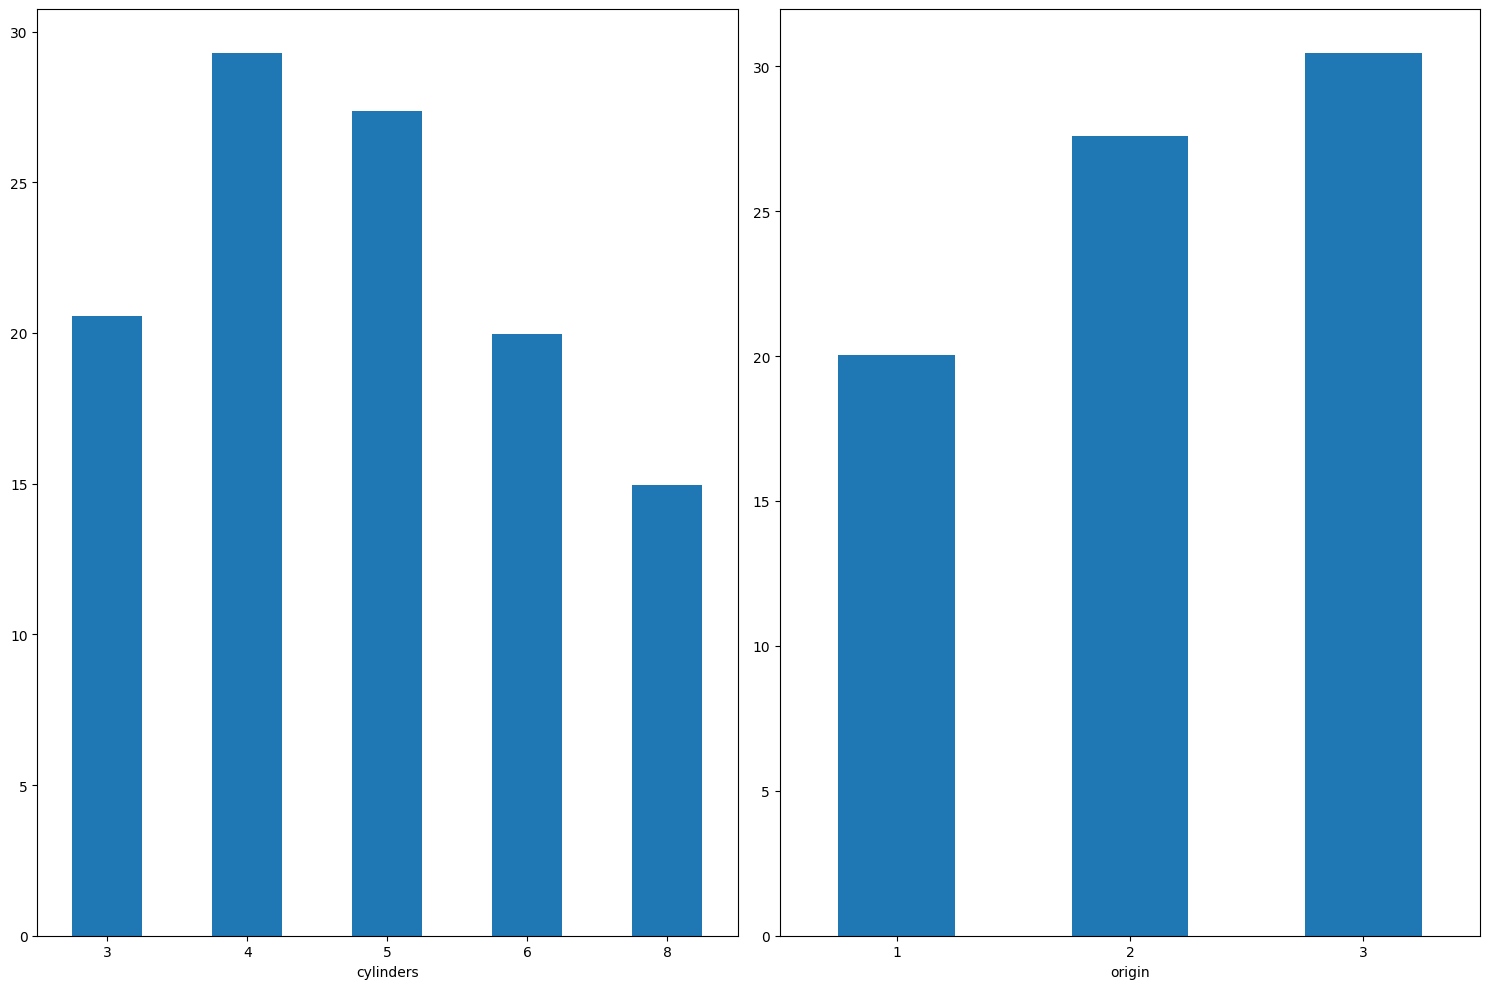

In [12]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(15,10))
for i, col in enumerate(['cylinders','origin']):
    plt.subplot(1,2,i+1)
    x= numeric_df.groupby(col).mean()['mpg']
    x.plot.bar()
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show


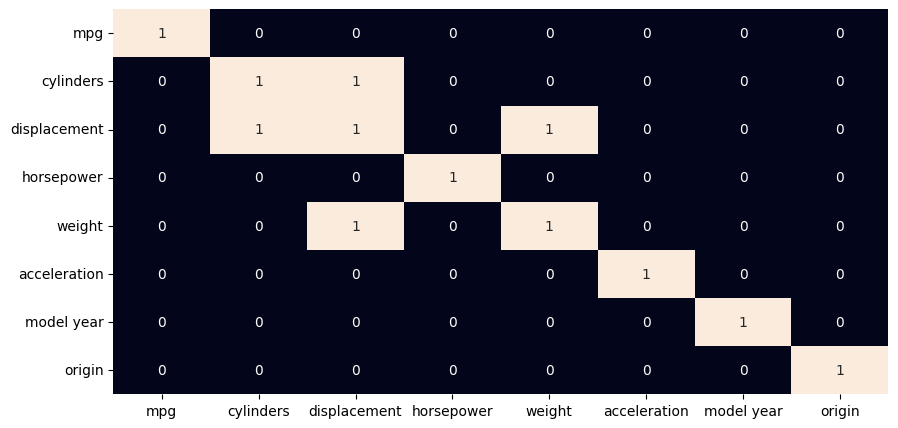

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap(numeric_df.corr()>0.9,
            annot=True,
            cbar=False)
plt.show()

In [14]:
df.drop('displacement',
        axis=1,
        inplace=True)

In [15]:
from sklearn.model_selection import train_test_split
features=df.drop(['mpg','car name'],axis=1)
target=df['mpg'].values
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=22)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((313, 6), (79, 6), (313,), (79,))

In [18]:
AUTO = tf.data.experimental.AUTOTUNE

train_ds=(
    tf.data.Dataset.from_tensor_slices((x_train,y_train))
    .batch(32)
    .prefetch(AUTO)
)

val_ds =(
    tf.data.Dataset.from_tensor_slices((x_test,y_test))
    .batch(32)
    .prefetch(AUTO)
)

In [21]:
model = keras.Sequential([
    layers.Dense(256,activation='relu',input_shape=[6]),
    layers.BatchNormalization(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1,activation='relu')
])

In [23]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,353 (142.00 KB)

 Trainable params: 35,585 (139.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [25]:
history = model.fit(train_ds,
                    epochs=50,
                    validation_data=val_ds)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 580.6190 - mae: 22.2041 - val_loss: 500.8129 - val_mae: 18.6275
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 551.1618 - mae: 20.9479 - val_loss: 319.4864 - val_mae: 15.2004
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 536.9827 - mae: 20.4894 - val_loss: 202.0394 - val_mae: 12.0784
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 523.6693 - mae: 20.1990 - val_loss: 177.4776 - val_mae: 10.8451
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 510.1502 - mae: 19.7533 - val_loss: 171.7734 - val_mae: 10.0544
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 497.7947 - mae: 19.2509 - val_loss: 177.7391 - val_mae: 10.1393
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 472.7589 - mae: 19.4176 - val_loss: 440.6216 - val_mae: 19.9457
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 381.8542 - mae: 18.7142 - val_loss: 570.2023 - val_mae: 22.3897
Epoch 9/50
10/10 ━━━━━━

In [26]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,565.933533,21.770144,500.812897,18.627506
1,542.691589,20.859396,319.486359,15.200412
2,529.424561,20.458345,202.039368,12.078391
3,515.785645,20.189220,177.477570,10.845098
4,501.465759,19.821356,171.773407,10.054420


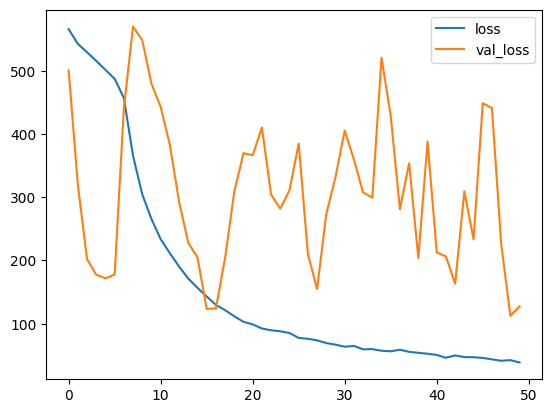

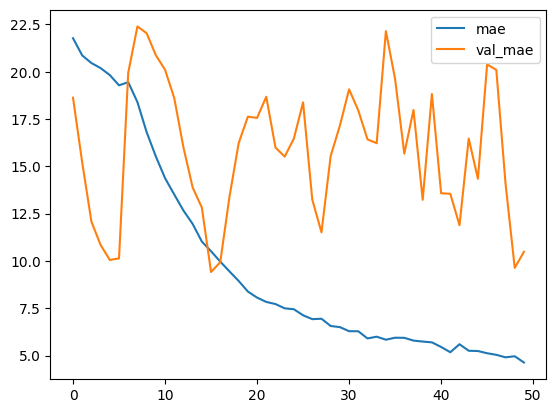

In [27]:
history_df.loc[:,['loss','val_loss']].plot()
history_df.loc[:,['mae','val_mae']].plot()
plt.show()